In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li

In [2]:
PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)
PCAData.rename(columns={"Unnamed: 0":"time"},inplace=True)

/tmp/ipykernel_53311/3375285327.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)


In [3]:
mainSeed = 971215
np.random.seed(mainSeed)

PCAHeaders = [str(i) for i in range(0,7)]

pumpList = PCAData["Well Run"].unique()

complexVib = PCAData["ESP Vibration X"]+1j*PCAData["ESP Vibration Y"]

PCAData["VibMod"] = np.absolute(complexVib)
PCAData["VibArc"] = np.angle(complexVib)
PCAData["Choke Closed"] = 1-PCAData["Choke Opening"]


X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=PCAData)

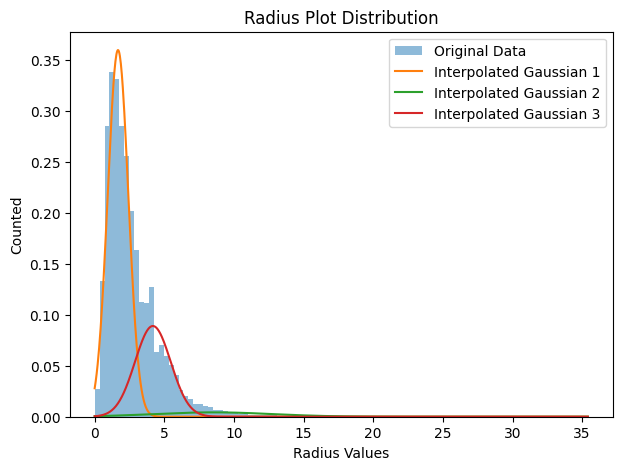

AIC: 1855314.832995263 BIC: 1855477.9310471676
[0.23642776 0.06867037 0.69490188]


In [4]:
n = 3
radiusData = PCAData["Radius"].loc[PCAData["Well_down"]==0]

model = li.GaussianMixtureFit(radiusData,n,seed=mainSeed)

li.GaussianMixturePlot(radiusData,model,[
    "Original Data",
    "Interpolated Gaussian",
    "Radius Plot Distribution",
    "Radius Values",
    "Counted"],
    figsize=(7,5))

modelRadius = hmm.GaussianHMM(
    n_components=n,
    random_state=mainSeed,
    covariance_type="full",
    init_params="st",
    algorithm="map"
    )

modelRadius.means_ = model.means_
modelRadius.covars__ = model.covariances_


modelRadius = li.HMMTrainer(X_train["Radius"],trainLength,modelRadius)

li.PostProcessing(modelRadius, PCAData, modelData,"Radius", "State Radius", totalLength)
print(modelRadius.get_stationary_distribution())
PCAData["State Radius"] = PCAData["State Radius"].map(li.StateConversion(modelRadius.get_stationary_distribution(),n))



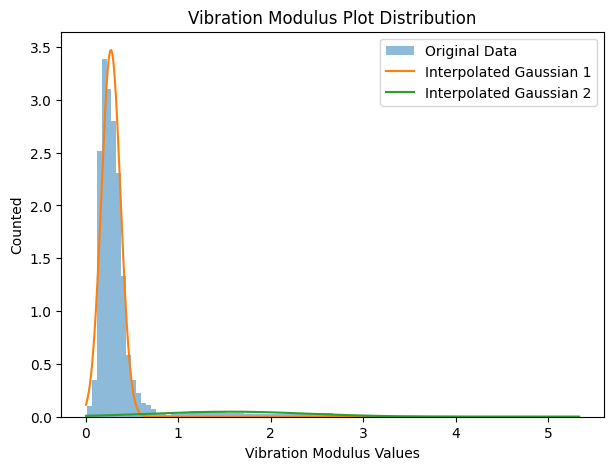

AIC: -924943.523738015 BIC: -924861.9747120626
[0.74783098 0.25216902]


In [5]:
n = 2

vibData= PCAData["VibMod"].loc[(PCAData["VibMod"]!=0) & (PCAData["Well_down"]==0)]

model = li.GaussianMixtureFit(vibData,n,seed=mainSeed)

li.GaussianMixturePlot(vibData,model,[
    "Original Data",
    "Interpolated Gaussian",
    "Vibration Modulus Plot Distribution",
    "Vibration Modulus Values",
    "Counted"])

modelVib = hmm.GaussianHMM(
    n_components=n,
    random_state=mainSeed,
    covariance_type="full",
    init_params="st",
    algorithm="map"
    )

modelVib.means_ = model.means_
modelVib.covars_ = model.covariances_

modelVib = li.HMMTrainer(X_train["VibMod"],trainLength,modelVib)

li.PostProcessing(modelVib, PCAData, modelData,"VibMod", "State Mod", totalLength)
print(modelVib.get_stationary_distribution())
PCAData["State Mod"] = PCAData["State Mod"].map(li.StateConversion(modelVib.get_stationary_distribution(),n))

PCAData.loc[(PCAData["VibMod"]==0) & (PCAData["Well_down"]==0),"State Mod"] = 3




In [6]:
vibeHeader = ["ESP Vibration X","ESP Vibration Y"]
esotericHeader = ['Water Cut @ 20degC - 1 atm', 'Choke Opening']

n = [3, 3]

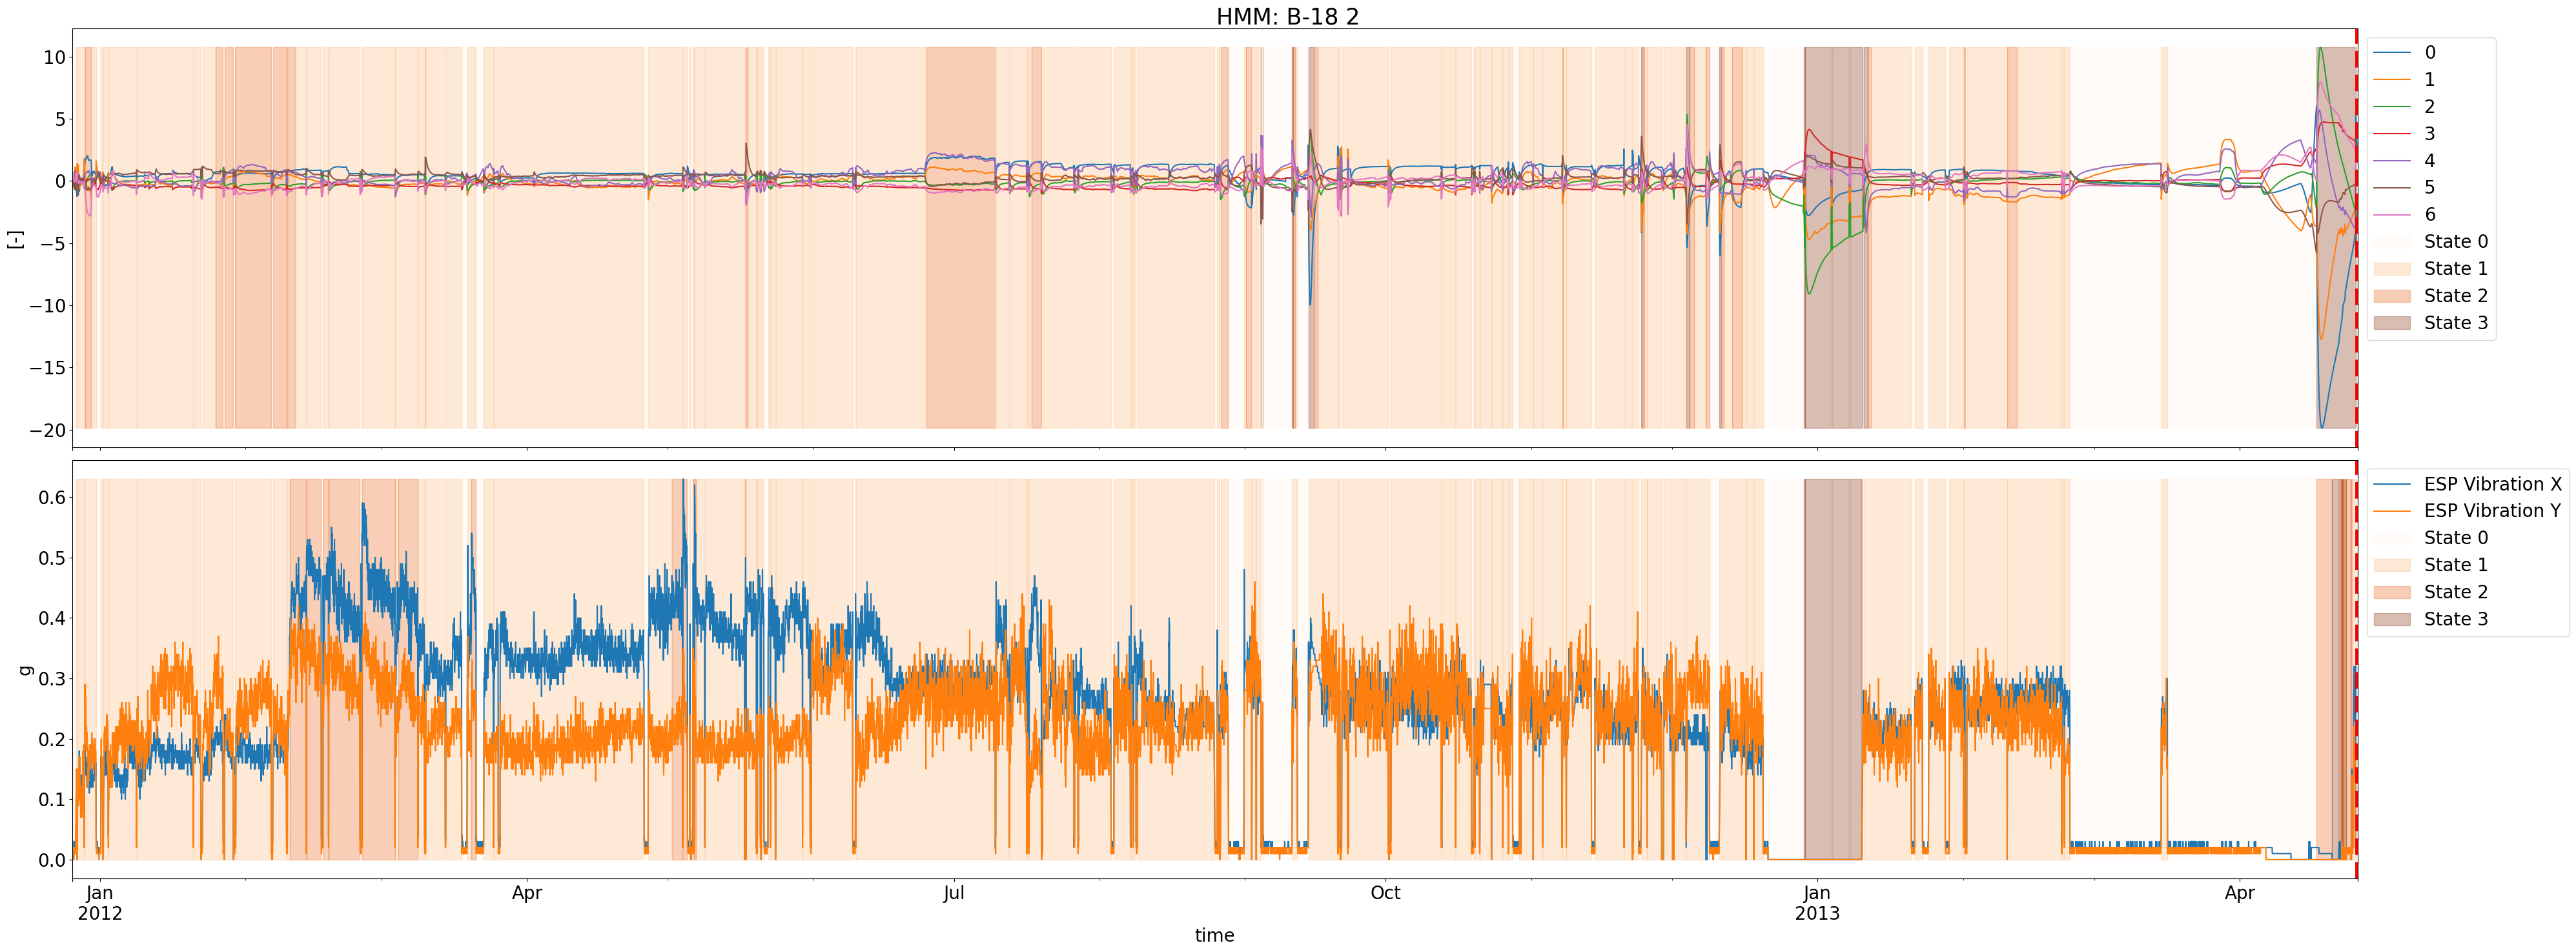

In [7]:
pump = pumpList[0]
pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
fig,axs = li.HMMPicture(pumpData,pump,props=[PCAHeaders,vibeHeader],measures=["[-]","g"],states=["State Radius","State Mod"], numberOfStates=n, figsize=(40,15))

fig.savefig("../imagens_gerais/b18-2markovrun.jpg")


In [8]:
# PCAData[["Transformed Radius","VibNormX","VibNormY"]] = 0.0

# for pump in pumpList:
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump]#.copy()
#     PCAData.loc[pumpData.index,"Transformed Radius"] = li.BoxCoxProccess(pumpData,"Radius")
#     # PCAData.loc[pumpData.index,"VibNormX"] = li.BoxCoxProccess(pumpData,"ESP Vibration X")
#     # PCAData.loc[pumpData.index,"VibNormY"] = li.BoxCoxProccess(pumpData,"ESP Vibration Y")

In [9]:
medianListR = np.array([])
medianListV = np.array([])

for pump in pumpList:
    pumpData = PCAData.loc[(PCAData["Well Run"]==pump) & (PCAData["Well_down"]==0) ]#.copy()
    last = pumpData.shape[0]
    pumpMedianR = pumpData.loc[pumpData.index[last-24:last-1],"State Radius"].median()
    medianListR = np.append(medianListR,pumpMedianR)
    pumpMedianV = pumpData.loc[pumpData.index[last-24:last-1],"State Mod"].median()
    medianListV = np.append(medianListV,pumpMedianV)




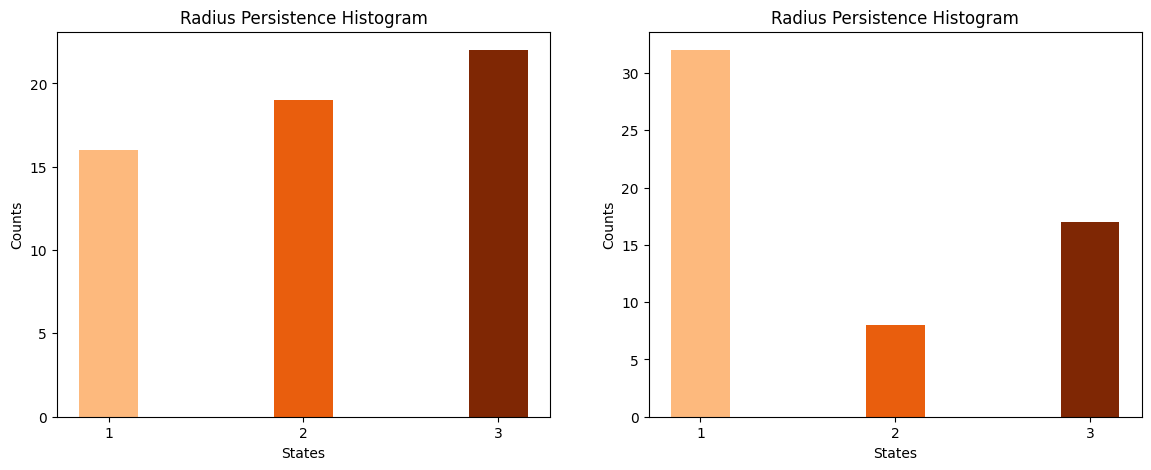

In [10]:
cmap = plt.get_cmap('Oranges', 4)
fig,axs=plt.subplots(1,2,figsize=(14,5))
states,counts = np.unique(medianListR,return_counts=True)
axs[0].bar(states,counts,width=0.3,color=[cmap(i) for i in range(1,cmap.N)])
axs[0].set_xticks(states,np.int64(states))
axs[0].set_ylabel("Counts")
axs[0].set_xlabel("States")
axs[0].set_title("Radius Persistence Histogram")

states,counts = np.unique(medianListV,return_counts=True)
axs[1].bar(states,counts,width=0.3,color=[cmap(i) for i in range(1,cmap.N)])
axs[1].set_xticks(states,np.int64(states))
axs[1].set_ylabel("Counts")
axs[1].set_xlabel("States")
axs[1].set_title("Radius Persistence Histogram")



plt.savefig("../imagens_gerais/radius_histogram.jpg")

In [11]:
from scipy.stats import chisquare

# Contagens das classes ao longo das inicializações
observed_counts = np.array([counts[0],counts[1],counts[2]]) # Substituir pelos valores reais
expected_counts = np.array([1/3, 1/3, 1/3]) * sum(observed_counts)

# Teste qui-quadrado de aderência
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
else:
    print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")


Estatística qui-quadrado: 15.4737, p-valor: 0.0004
Rejeitamos H0: C ocorre significativamente mais do que o esperado.


In [12]:
cmap = plt.get_cmap('Oranges', 4)
plt.figure(figsize=(7,5))

states,counts = np.unique(medianList,return_counts=True)
plt.bar(states,counts,width=0.3, color=[cmap(i) for i in range(1,cmap.N)])
plt.xticks(states,np.int64(states))
plt.ylabel("Counts")
plt.xlabel("States")
plt.title("Vibration Modulus Persistence Histogram")
plt.savefig("../imagens_gerais/vibration_histogram.jpg")

NameError: name 'medianList' is not defined

<Figure size 700x500 with 0 Axes>

In [ ]:
# Contagens das classes ao longo das inicializações
observed_counts = counts  # Substituir pelos valores reais
expected_counts = np.array([1/3, 1/3, 1/3]) * sum(observed_counts)

# Teste qui-quadrado de aderência
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
else:
    print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")


Estatística qui-quadrado: 15.4737, p-valor: 0.0004
Rejeitamos H0: C ocorre significativamente mais do que o esperado.


In [ ]:
for pump in pumpList:
   
    pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()

    # fig, axs =li.HMMPicture(
    #     pumpData,
    #     pump,
    #     props=[PCAHeaders,vibeHeader],
    #     states=["State Radius","State Mod"],
    #     numberOfStates=n,
    #     figsize=(40,15)
    #     )

    # fig.savefig("../imagensFinaisHMM/heatmap-"+pump+".png")
    # plt.close()
    onlineData = pumpData.loc[pumpData["Well_down"]==0]
    plt.figure(figsize=(10,10))
    plt.scatter(onlineData["Water Cut @ 20degC - 1 atm"],onlineData["Choke Closed"],c=onlineData["State Radius"],s=onlineData["Radius"])
    plt.xlabel("Water Cut @ 20degC - 1 atm")
    plt.ylabel("Choke Closed")
    plt.savefig("../choke_per_watercut/"+pump+".png")
    plt.close()


Text(0, 0.5, 'Choke Closed')

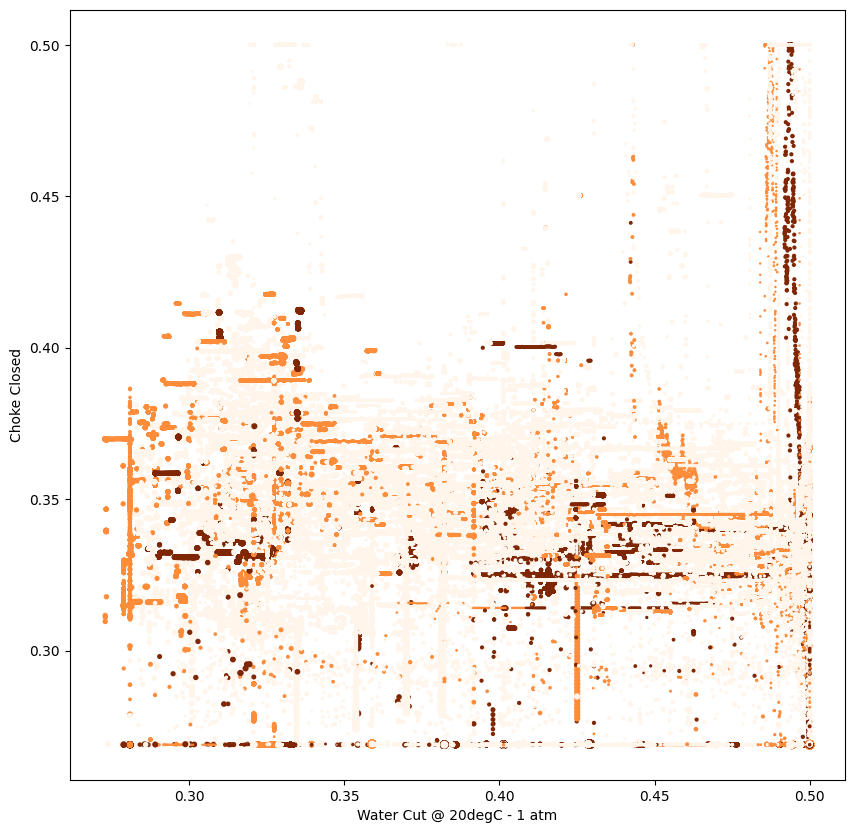

In [ ]:
onlineData = PCAData.loc[PCAData["Well_down"]==0]

x = 1/(1+onlineData["Water Cut @ 20degC - 1 atm"].apply(np.exp))
y = 1/(1+onlineData["Choke Closed"].apply(np.exp))

plt.figure(figsize=(10,10))
plt.scatter(x,y,c=onlineData["State Mod"],s=onlineData["Radius"],cmap='Oranges')
plt.xlabel("Water Cut @ 20degC - 1 atm")
plt.ylabel("Choke Closed")
# plt.savefig("../choke_per_watercut/"+pump+".png")
# plt.close()

In [ ]:
PCAData["Transformed Radius"].hist(bins=500, figsize=(10,5))
plt.title("Histograma da Transformação do Raio")

KeyError: 'Transformed Radius'

Text(0.5, 1.0, 'Histograma do Raio')

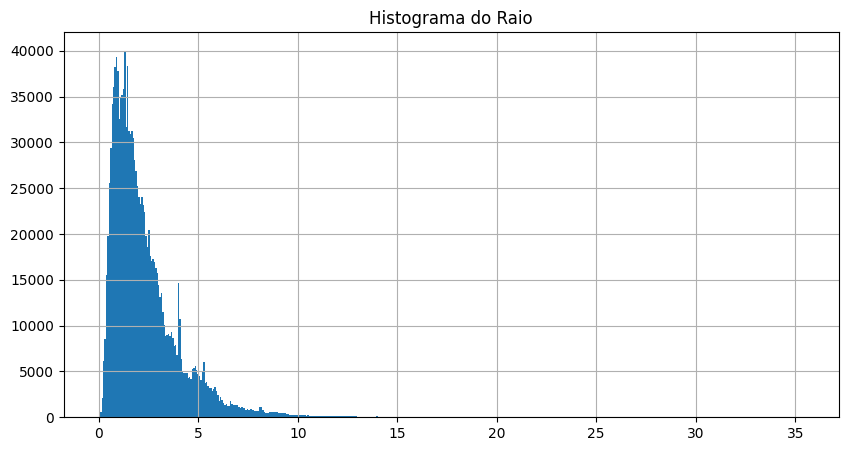

In [ ]:
PCAData["Radius"].hist(bins=500,figsize=(10,5))
plt.title("Histograma do Raio")

In [ ]:
# PCAData["Radius Category"] = pd.qcut(PCAData["Radius"],q=[0,.75,.95,1],labels=[1,2,3]).astype(int)
# PCAData["Radius Category"].hist()
# PCAData["Radius"].describe()

# modelCat = modelCat = hmm.CategoricalHMM(n_components=2,random_state=mainSeed)
# modelCat = li.HMMTrainer(X_train["Radius Category"],trainLength,modelCat)
# li.PostProcessing(modelCat, PCAData, modelData,"Radius Category", "State Cat", totalLength)
# print(modelCat.get_stationary_distribution())
# PCAData["State Cat"] = PCAData["State Cat"].map(li.StateConversion(modelCat.get_stationary_distribution(),2))


In [ ]:
# #modelSq = li.HiddenMarkovModel(X_train["Transformed Radius"], trainLength, mainSeed, n[0],covar_type="diag")
# # pickle.dump(modelSq,open("MLmodels/modelSq.sav","wb"))

# modelSq = pickle.load(open("MLmodels/modelSq.sav","rb"))

# li.PostProcessing(modelSq, PCAData, modelData,"Transformed Radius", "State Gaussian", totalLength)
# print(modelSq.get_stationary_distribution())
# PCAData["State Gaussian"] = PCAData["State Gaussian"].map(li.StateConversion(modelSq.get_stationary_distribution(),n[0]))

# #modelVib = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY"]], trainLength, mainSeed, n[1],covar_type="full")
# # pickle.dump(modelVib,open("MLmodels/modelVib.sav","wb"))

# modelVib = pickle.load(open("MLmodels/modelVib.sav","rb"))
# li.PostProcessing(modelVib, PCAData, modelData,["VibNormX","VibNormY"], "State Vib", totalLength)
# print(modelVib.get_stationary_distribution())
# PCAData["State Vib"] = PCAData["State Vib"].map(li.StateConversion(modelVib.get_stationary_distribution(),n[1]))

# #modelTot = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY","Transformed Radius"]], trainLength, mainSeed, n[2],covar_type="full")
# #pickle.dump(modelTot,open("MLmodels/modelTot.sav","wb"))

# modelTot = pickle.load(open("MLmodels/modelTot.sav","rb"))
# li.PostProcessing(modelTot, PCAData, modelData,["VibNormX","VibNormY","Transformed Radius"], "State Tot", totalLength)
# print(modelTot.get_stationary_distribution())
# PCAData["State Tot"] = PCAData["State Tot"].map(li.StateConversion(modelTot.get_stationary_distribution(),n[2]))


# for pump in pumpList:
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
#     fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)
#     fig.savefig("../imagensHMM/"+pump)
#     plt.close()

In [ ]:
# numberOfDays = 7

# stats = pd.DataFrame(columns=["State Vib", "State Gaussian","State Tot"])

# for pump in pumpList:
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump]
#     if pumpData.loc[pumpData["Failure"]==1].empty != True:
#         failure = pumpData.loc[pumpData["Failure"]==1].index[0]
#         indexRef = pumpData.index[0]
#         selectedData = pumpData.iloc[failure-indexRef-numberOfDays*24:]

#         stats = pd.concat([stats, 
#                        selectedData.loc[selectedData["Well_down"]==0][["State Vib", "State Gaussian","State Tot"]]])

    

In [ ]:
# stats.reset_index(inplace=True,drop=True)
# stats = stats.infer_objects()
# stats.drop(labels=0,inplace=True)
# stats.hist()


In [ ]:
# modelSq = li.HiddenMarkovModel(X_train["Transformed Radius"], trainLength, mainSeed, n[0],algorithm="map")
# li.PostProcessing(modelSq, PCAData, modelData,"Transformed Radius", "State Gaussian", totalLength)
# print(modelSq.get_stationary_distribution())
# PCAData["State Gaussian"] = PCAData["State Gaussian"].map(li.StateConversion(modelSq.get_stationary_distribution(),n[0]))
# pickle.dump(modelSq,open("modelSq_map.sav","wb"))

# modelVib = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY"]], trainLength, mainSeed, n[1],algorithm="map")
# li.PostProcessing(modelVib, PCAData, modelData,["VibNormX","VibNormY"], "State Vib", totalLength)
# print(modelVib.get_stationary_distribution())
# PCAData["State Vib"] = PCAData["State Vib"].map(li.StateConversion(modelVib.get_stationary_distribution(),n[1]))
# pickle.dump(modelVib,open("modelVib_map.sav","wb"))

# modelTot = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY","Transformed Radius"]], trainLength, mainSeed, n[2],algorithm="map")
# li.PostProcessing(modelTot, PCAData, modelData,["VibNormX","VibNormY","Transformed Radius"], "State Tot", totalLength)
# print(modelTot.get_stationary_distribution())
# PCAData["State Tot"] = PCAData["State Tot"].map(li.StateConversion(modelTot.get_stationary_distribution(),n[2]))
# pickle.dump(modelTot,open("modelTot.sav","wb"))

# for pump in pumpList:
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
#     fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)
#     fig.savefig("../imagensHMM_map/"+pump)
#     plt.close()

In [ ]:
# pump = pumpList[0]

# pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
# fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)

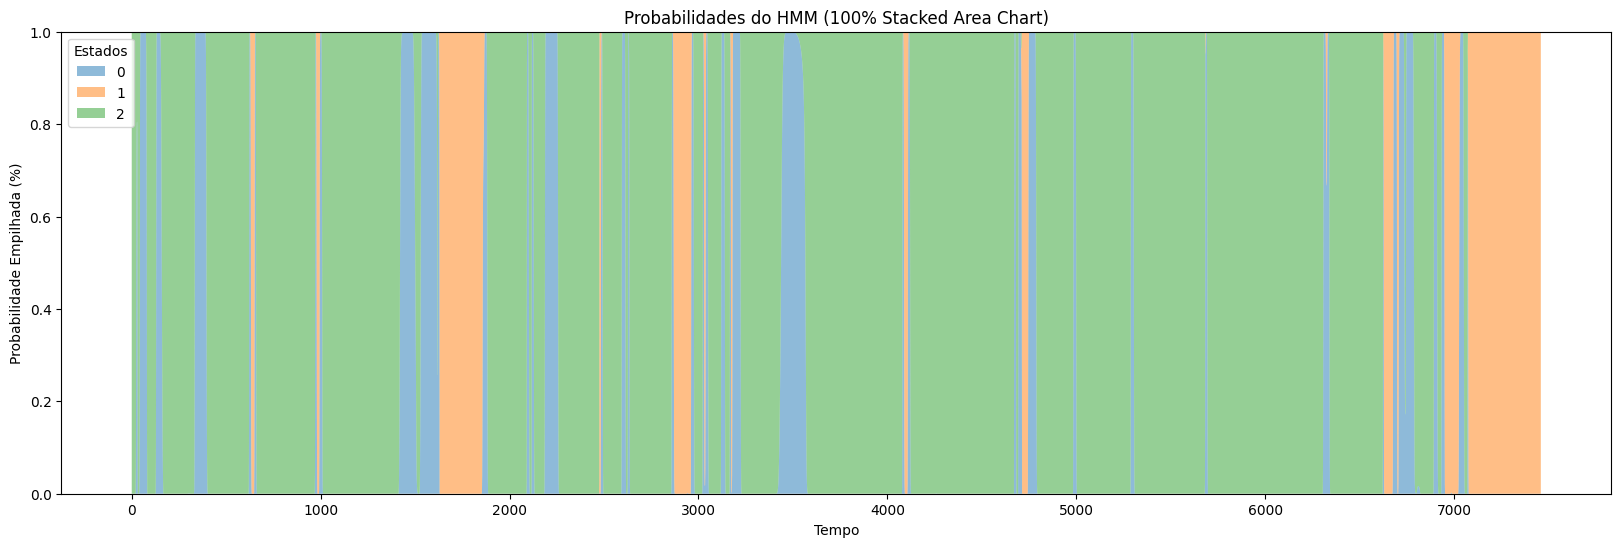

In [ ]:
totalReshaped = pumpData["Radius"].loc[pumpData["Well_down"]==0].to_numpy().reshape(-1,1)


df = pd.DataFrame(modelRadius.predict_proba(totalReshaped))

# Índices de tempo
time = np.arange(len(df))

# Criar figura
fig, ax = plt.subplots(figsize=(20, 6))

# Cores para os estados
colors = ['#1f77b4', '#ff7f0e', '#2ca02c','#4cff2c','#fcff2c']

# Gráfico de área empilhada com transparência (alpha)
ax.stackplot(time, df.T, labels=df.columns, colors=colors, alpha=0.5)

# Configurações do gráfico
ax.set_xlabel("Tempo")
ax.set_ylabel("Probabilidade Empilhada (%)")
ax.set_title("Probabilidades do HMM (100% Stacked Area Chart)")
ax.legend(title="Estados", loc='upper left')
plt.ylim(0, 1)  # Mantém o eixo Y de 0 a 1 (100%)

# Exibir o gráfico
plt.show()


In [ ]:
# for pump in pumpList:
   
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()

#     fig, axs = li.HMMPicture(pumpData,pump,PCAHeaders,cmap1,n_1)

#     fig.savefig("imagens/heatmap2/heatmap-"+pump+".png")
#     plt.close()

In [ ]:
# import dynamax.hidden_markov_model as hmm


# model = hmm.LinearAutoregressiveHMM(num_states=4,emission_dim=5)
# model.fit_em()


#  pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()

#     pumpData["time"] = pd.to_datetime(pumpData["time"])
#     pumpData.set_index("time",inplace=True)

#     pumpData = pumpData.asfreq('h',fill_value=0)

#     pumpData["Shutdown"] = pumpData["Well_down"] != pumpData["Well_down"].shift(-1).fillna(pumpData["Well_down"].iloc[-1])

#     fig, ax = plt.subplots(4,1, figsize=(50,15))

#     pumpData[PCAHeaders].plot(ax=ax[0])


#     # Preenchendo as áreas de acordo com os estados
#     for state in np.unique(states):
#         color = cmap(state)  # Pega uma cor automática para cada estado
#         ax[0].fill_between(pumpData.index, np.min(pumpData[PCAHeaders]), np.max(pumpData[PCAHeaders]), where=(pumpData["State"] == state), 
#                         color=color, alpha=0.3, label=f"Estado {state}")
        
#     ax[0].legend(loc='upper left',bbox_to_anchor=(1, 1))


#     # for shut in pumpData["Shutdown"].loc[pumpData["Shutdown"] == True].index:
#     #       ax[0].axvline(x=shut, color='black', linestyle='-', linewidth=0.5)





#     norm = mcolors.Normalize(vmin=-6, vmax=6)

#     its = ax[3].pcolor(pumpData[PCAHeaders].T,cmap='hsv', norm=norm)
#     ax[3].grid(axis="y",linewidth=1,color="black")
#     ax[3].tick_params(axis='both', which='both', length=0)  # Remove ticks
#     ax[3].set_xticklabels([])  # Remove labels no eixo x


#     ax[3].set_title(str(pumpData["Pump Info"].iloc[0])+" "+str(pumpData["Failure Info"].iloc[0]))




#     if pumpData.loc[pumpData["Failure"]==True].shape[0] != 0:
#             failureX = pumpData.index.get_loc(pumpData.loc[pumpData["Failure"]==True].index[0])
#             ax[3].axvline(x=failureX, color='red', linestyle='--', linewidth=1)


#     fig.colorbar(its,ax=ax[3],orientation='horizontal',shrink=0.5)


#     fig.suptitle("HMM e Imshow: " + pump);
#     plt.tight_layout()
#     fig.savefig("imagens/heatmap2/heatmap-"+pump+".png")
#     plt.close()

In [ ]:
# pump = pumpList[0]
# pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
# plt.rcParams['font.size'] = 15.0
# pumpData["time"] = pd.to_datetime(pumpData["time"])
# pumpData.set_index("time",inplace=True)

# pumpData = pumpData.asfreq('h',fill_value=0)

# pumpData["Shutdown"] = pumpData["Well_down"] != pumpData["Well_down"].shift(-1).fillna(pumpData["Well_down"].iloc[-1])


# fig, ax = plt.subplots(1,1, figsize=(20,10))

# pumpData[PCAHeaders].plot(ax=ax)


# # Preenchendo as áreas de a
# # cordo com os estados
# for state in np.unique(states):
#         color = cmap(state)  # Pega uma cor automática para cada estado
#         ax.fill_between(pumpData.index, np.min(pumpData[PCAHeaders]), np.max(pumpData[PCAHeaders]), where=(pumpData["State"] == state), 
#                         color=color, alpha=0.3, label=f"State {state}")

#         ax.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)



# if pumpData.loc[pumpData["Failure"]==True].shape[0] != 0:
#         #failureX = pumpData.index.get_loc(pumpData.loc[pumpData["Failure"]==True].index[0])
#         ax.axvline(x=pumpData.loc[pumpData["Failure"]==True].index[0], color='red', linestyle='--', linewidth=5)


# fig.suptitle("HMM: " + pump,fontsize=20);
# fig.savefig("imagens/relatorio/hmm")